# Image Color Compression — 01 Exploratory Data Analysis

**Unsupervised** project. Each pixel of an image is a point in 3-D RGB space (values 0–255 per channel). A typical photo contains tens of thousands of distinct colours. The goal of this project is to **compress the colour palette** down to `k` colours with K-Means clustering, while keeping the image visually close to the original.

This notebook explores the two sample images we will compress.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import utils

china = utils.load_image('data/china.png')
flower = utils.load_image('data/flower.png')
print('china :', china.shape, china.dtype)
print('flower:', flower.shape, flower.dtype)

china : (427, 640, 3) uint8
flower: (427, 640, 3) uint8


## 1. The images

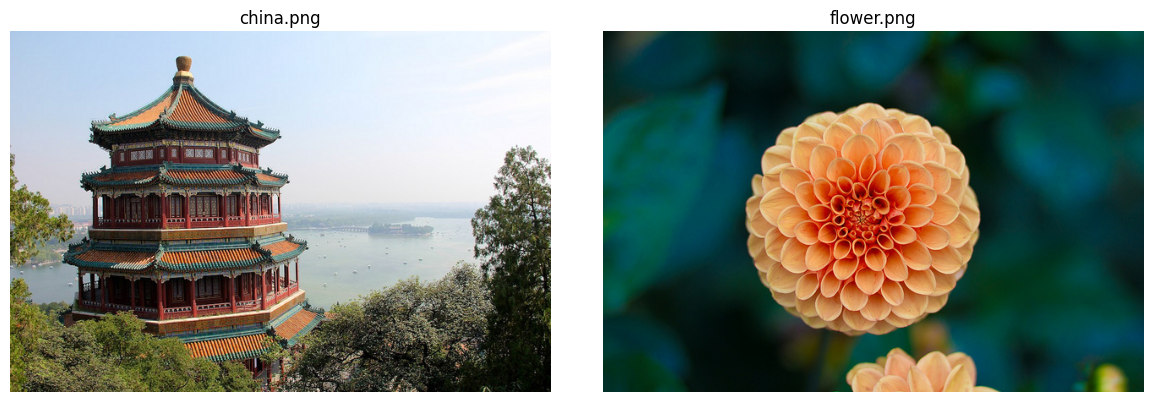

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(china);  ax[0].set_title('china.png');  ax[0].axis('off')
ax[1].imshow(flower); ax[1].set_title('flower.png'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 2. Dataset overview

Each image is an `(H, W, 3)` array. `H*W` is the number of pixels — the number of rows we feed to K-Means. The number of **unique colours** tells us how much room there is to compress.

In [3]:
for name, img in [('china', china), ('flower', flower)]:
    h, w, c = img.shape
    n_pixels = h * w
    n_colors = utils.count_unique_colors(img)
    print(f'{name:7s} | {h}x{w} = {n_pixels:,} pixels | {n_colors:,} unique colours '
          f'| {100*n_colors/n_pixels:5.1f}% of pixels are a unique colour')

china   | 427x640 = 273,280 pixels | 96,615 unique colours |  35.4% of pixels are a unique colour
flower  | 427x640 = 273,280 pixels | 62,941 unique colours |  23.0% of pixels are a unique colour


## 3. Colour-channel distributions (china)

Histograms of the Red, Green and Blue channels show how pixel intensities are spread. Clusters/peaks here hint at the dominant colours K-Means will discover.

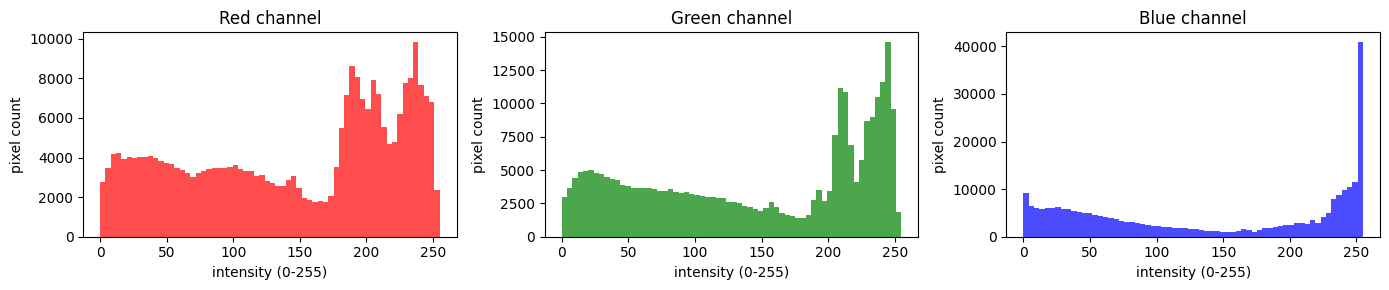

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3))
colors = ['red', 'green', 'blue']
for i, col in enumerate(colors):
    ax[i].hist(china[..., i].ravel(), bins=64, color=col, alpha=0.7)
    ax[i].set_title(f'{col.capitalize()} channel')
    ax[i].set_xlabel('intensity (0-255)'); ax[i].set_ylabel('pixel count')
plt.tight_layout(); plt.show()

## 4. Pixels in RGB space (china)

A random sample of pixels plotted in 3-D, each dot painted its own colour. K-Means will partition this cloud into `k` blobs and replace every point with its blob centre — that is exactly what colour compression does.

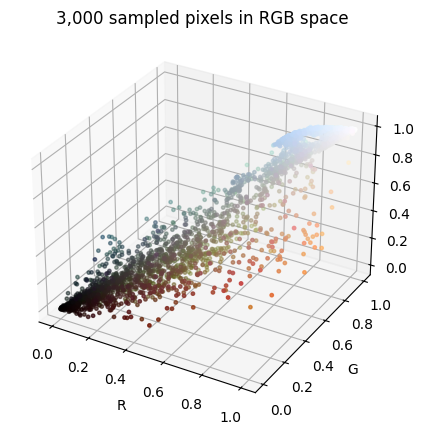

In [5]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
X, _ = utils.image_to_pixels(china)
rng = np.random.RandomState(42)
idx = rng.choice(len(X), 3000, replace=False)
sample = X[idx]
fig = plt.figure(figsize=(6, 5))
axx = fig.add_subplot(111, projection='3d')
axx.scatter(sample[:, 0], sample[:, 1], sample[:, 2], c=sample, s=6)
axx.set_xlabel('R'); axx.set_ylabel('G'); axx.set_zlabel('B')
axx.set_title('3,000 sampled pixels in RGB space'); plt.show()

## 5. Summary of findings

- Both images are **427 × 640 = 273,280 pixels**.
- `china.png` holds **96,615 unique colours**, `flower.png` **62,941** — both far more than a small palette needs, so there is heavy redundancy to compress.
- The RGB scatter shows pixels are **not uniformly spread** but cluster along a few directions — exactly the structure K-Means exploits.
- Next: notebook **02** reshapes the image into the pixel matrix K-Means consumes.